In [9]:
import benefits_defns

In [12]:
import importlib 
importlib.reload(benefits_defns)
from benefits_defns import *

In [2]:
import pandas as pd 
import numpy as np

In [3]:
path = '../../data/salary_sample_body_benefits_v3.parquet.gzip'

In [4]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [5]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,False,True,False,True,False,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,False,False,None Listed,10.635855
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,3-5 years,10.551899
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,True,True,True,True,False,True,True,False,None Listed,10.097573
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,1-2 years,10.544288


In [17]:
pd.set_option('display.max_rows', 300)
even_sample.groupby([occupation, 'YEAR','AI ROLE']).size()

SOC_2021_2_NAME                                             YEAR  AI ROLE
Architecture and Engineering Occupations                    2019  False        11
                                                                  True         16
                                                            2020  False        13
                                                                  True         18
                                                            2021  False        31
                                                                  True         36
                                                            2022  False        38
                                                                  True         73
                                                            2023  False        42
                                                                  True        151
Arts, Design, Entertainment, Sports, and Media Occupations  2019  False        22
                        

In [19]:
occupations_select = ['Architecture and Engineering Occupations','Arts, Design, Entertainment, Sports, and Media Occupations','Business and Financial Operations Occupations','Community and Social Service Occupations','Computer and Mathematical Occupations',
'Educational Instruction and Library Occupations',
'Healthcare Practitioners and Technical Occupations',
'Legal Occupations',
'Life, Physical, and Social Science Occupations',
'Management Occupations', 
'Office and Administrative Support Occupations',
'Personal Care and Service Occupations', 'Production Occupations',
'Sales and Related Occupations',
'Transportation and Material Moving Occupations',
]

In [20]:
even_sample_select = even_sample[even_sample[occupation].isin(occupations_select)]

# AI Role Demand Over Time

In [115]:
ai_role_raw = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].sum().reset_index()

In [118]:
role_total = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].count().reset_index()

In [119]:
role_total

,SOC_2021_2_NAME,YEAR,AI ROLE
0,Architecture and Engineering Occupations,2019,27
1,Architecture and Engineering Occupations,2020,31
2,Architecture and Engineering Occupations,2021,67
3,Architecture and Engineering Occupations,2022,111
4,Architecture and Engineering Occupations,2023,193
5,"Arts, Design, Entertainment, Sports, and Media...",2019,35
6,"Arts, Design, Entertainment, Sports, and Media...",2020,43
7,"Arts, Design, Entertainment, Sports, and Media...",2021,63
8,"Arts, Design, Entertainment, Sports, and Media...",2022,92
9,"Arts, Design, Entertainment, Sports, and Media...",2023,199


In [117]:
ai_role_raw

,SOC_2021_2_NAME,YEAR,AI ROLE
0,Architecture and Engineering Occupations,2019,16
1,Architecture and Engineering Occupations,2020,18
2,Architecture and Engineering Occupations,2021,36
3,Architecture and Engineering Occupations,2022,73
4,Architecture and Engineering Occupations,2023,151
5,"Arts, Design, Entertainment, Sports, and Media...",2019,13
6,"Arts, Design, Entertainment, Sports, and Media...",2020,14
7,"Arts, Design, Entertainment, Sports, and Media...",2021,23
8,"Arts, Design, Entertainment, Sports, and Media...",2022,41
9,"Arts, Design, Entertainment, Sports, and Media...",2023,135


In [26]:
ai_role_occupation = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].mean().reset_index()


In [28]:
ai_role_occupation.rename(columns={'AI ROLE':'AI ROLE %'}, inplace=True)

In [29]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %
0,Architecture and Engineering Occupations,2019,0.592593
1,Architecture and Engineering Occupations,2020,0.580645
2,Architecture and Engineering Occupations,2021,0.537313
3,Architecture and Engineering Occupations,2022,0.657658
4,Architecture and Engineering Occupations,2023,0.782383
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392


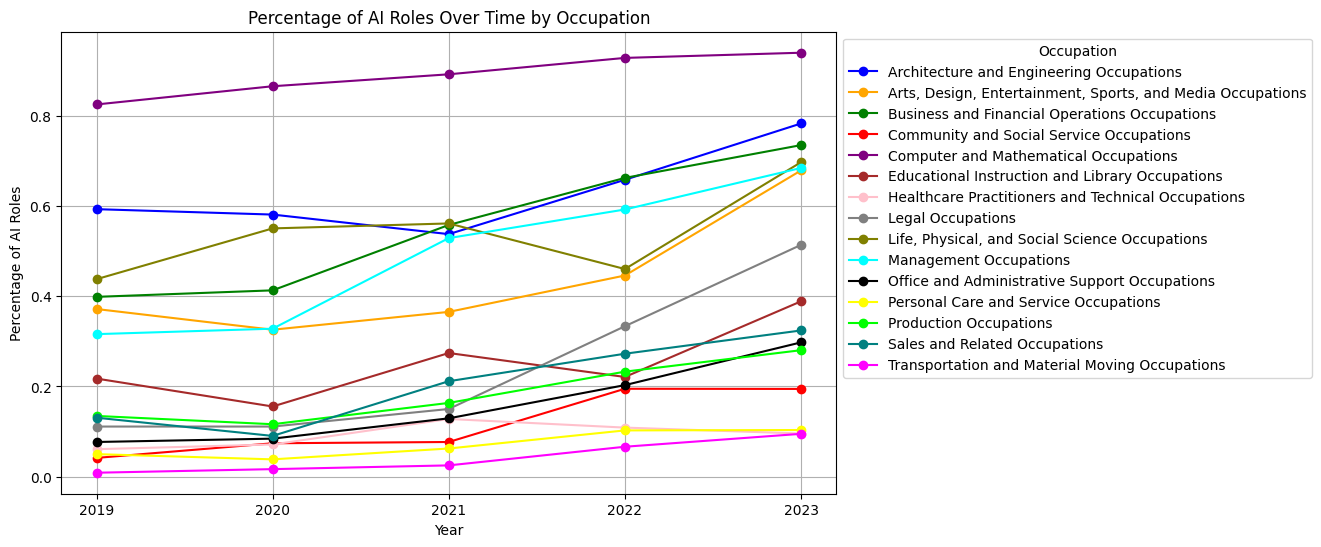

In [35]:
import matplotlib.pyplot as plt

# use different colors for each occupation
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'black', 'yellow', 'lime', 'teal', 'magenta']

# Create a pivot table where the index is 'YEAR' and columns are 'occupation'
pivot_data = ai_role_occupation.pivot(index='YEAR', columns=occupation, values='AI ROLE %')

# Plot each occupation's percentage of AI roles over time
pivot_data.plot(figsize=(10, 6), marker='o', color=colors)

# Adding titles and labels
plt.title('Percentage of AI Roles Over Time by Occupation')
# make x ticks only year integers
plt.xticks(np.arange(pivot_data.index.min(), pivot_data.index.max()+1, 1.0))
plt.xlabel('Year')
plt.ylabel('Percentage of AI Roles')
plt.legend(title='Occupation', bbox_to_anchor=(1, 1))
plt.grid(True)

# Show the plot
plt.show()


In [31]:
pivot_data

SOC_2021_2_NAME,Architecture and Engineering Occupations,"Arts, Design, Entertainment, Sports, and Media Occupations",Business and Financial Operations Occupations,Community and Social Service Occupations,Computer and Mathematical Occupations,Educational Instruction and Library Occupations,Healthcare Practitioners and Technical Occupations,Legal Occupations,"Life, Physical, and Social Science Occupations",Management Occupations,Office and Administrative Support Occupations,Personal Care and Service Occupations,Production Occupations,Sales and Related Occupations,Transportation and Material Moving Occupations
YEAR,,,,,,,,,,,,,,,
2019,0.592593,0.371429,0.398374,0.041667,0.824519,0.217391,0.060976,0.111111,0.437500,0.315789,0.076923,0.050000,0.134615,0.130719,0.008850
2020,0.580645,0.325581,0.412791,0.074074,0.864865,0.155556,0.071429,0.111111,0.550000,0.327869,0.084337,0.038462,0.116279,0.090361,0.016807
2021,0.537313,0.365079,0.557621,0.076923,0.891304,0.273973,0.127907,0.150000,0.560976,0.528517,0.129338,0.062500,0.163462,0.211538,0.025090
2022,0.657658,0.445652,0.661856,0.194805,0.927632,0.220930,0.108787,0.333333,0.460000,0.591876,0.202864,0.102564,0.232704,0.272425,0.066406
2023,0.782383,0.678392,0.734472,0.194444,0.939111,0.388489,0.095652,0.513514,0.696629,0.683908,0.297539,0.103448,0.280255,0.323944,0.095000


# % Roles Offering Benefit for AI/Non-AI Roles

In [39]:
occupation_benefits = even_sample_select.groupby([occupation, 'YEAR', 'AI ROLE'])[benefits3].mean().reset_index()

In [40]:
occupation_benefits

,SOC_2021_2_NAME,YEAR,AI ROLE,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE
0,Architecture and Engineering Occupations,2019,False,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Architecture and Engineering Occupations,2019,True,0.187500,0.000000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Architecture and Engineering Occupations,2020,False,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Architecture and Engineering Occupations,2020,True,0.166667,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111
4,Architecture and Engineering Occupations,2021,False,0.129032,0.096774,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Architecture and Engineering Occupations,2021,True,0.250000,0.138889,0.333333,0.000000,0.027778,0.000000,0.055556,0.055556,0.027778
6,Architecture and Engineering Occupations,2022,False,0.236842,0.184211,0.447368,0.026316,0.026316,0.000000,0.078947,0.078947,0.000000
7,Architecture and Engineering Occupations,2022,True,0.260274,0.178082,0.424658,0.000000,0.013699,0.041096,0.041096,0.041096,0.095890
8,Architecture and Engineering Occupations,2023,False,0.166667,0.119048,0.428571,0.071429,0.047619,0.071429,0.071429,0.071429,0.166667
9,Architecture and Engineering Occupations,2023,True,0.258278,0.158940,0.470199,0.072848,0.092715,0.033113,0.145695,0.145695,0.185430


In [41]:
benefits_ai = occupation_benefits[occupation_benefits['AI ROLE'] == 1]
benefits_non_ai = occupation_benefits[occupation_benefits['AI ROLE'] == 0]

In [67]:
merged_df = pd.merge(benefits_ai, benefits_non_ai, on=['SOC_2021_2_NAME', 'YEAR'], suffixes=('_ai', '_non_ai'))


In [87]:
for benefit in benefits3:
    merged_df[f'{benefit}_premium'] = ((merged_df[f'{benefit}_ai'] - (merged_df[f'{benefit}_non_ai']
                                                                      ))*100).round(3)


In [88]:
for benefit in benefits3:
    merged_df[f'{benefit}_premium'] = merged_df[f'{benefit}_premium'].apply(lambda x: f'{x:.3f}' if pd.notnull(x) else x)

In [89]:
pd.set_option('display.max_columns', 300)

In [90]:
merged_df

,SOC_2021_2_NAME,YEAR,AI ROLE_ai,CAREER_DEV_ai,EDU_ASSISTANCE_ai,WLB_ai,WELLBEING_ai,HEALTH_WELLBEING_ai,RECOGNITION_ai,FAMILY_ai,PARENTAL_LEAVE_ai,CULTURE_ai,AI ROLE_non_ai,CAREER_DEV_non_ai,EDU_ASSISTANCE_non_ai,WLB_non_ai,WELLBEING_non_ai,HEALTH_WELLBEING_non_ai,RECOGNITION_non_ai,FAMILY_non_ai,PARENTAL_LEAVE_non_ai,CULTURE_non_ai,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,2019,True,0.187500,0.000000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000
1,Architecture and Engineering Occupations,2020,True,0.166667,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,False,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111
2,Architecture and Engineering Occupations,2021,True,0.250000,0.138889,0.333333,0.000000,0.027778,0.000000,0.055556,0.055556,0.027778,False,0.129032,0.096774,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778
3,Architecture and Engineering Occupations,2022,True,0.260274,0.178082,0.424658,0.000000,0.013699,0.041096,0.041096,0.041096,0.095890,False,0.236842,0.184211,0.447368,0.026316,0.026316,0.000000,0.078947,0.078947,0.000000,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589
4,Architecture and Engineering Occupations,2023,True,0.258278,0.158940,0.470199,0.072848,0.092715,0.033113,0.145695,0.145695,0.185430,False,0.166667,0.119048,0.428571,0.071429,0.047619,0.071429,0.071429,0.071429,0.166667,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876
5,"Arts, Design, Entertainment, Sports, and Media...",2019,True,0.153846,0.000000,0.230769,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.136364,0.045455,0.363636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000
6,"Arts, Design, Entertainment, Sports, and Media...",2020,True,0.214286,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.034483,0.034483,0.206897,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000
7,"Arts, Design, Entertainment, Sports, and Media...",2021,True,0.086957,0.000000,0.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.086957,False,0.150000,0.075000,0.300000,0.000000,0.025000,0.025000,0.050000,0.050000,0.025000,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196
8,"Arts, Design, Entertainment, Sports, and Media...",2022,True,0.146341,0.048780,0.365854,0.048780,0.048780,0.000000,0.024390,0.024390,0.121951,False,0.156863,0.058824,0.313725,0.039216,0.058824,0.019608,0.039216,0.039216,0.019608,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234
9,"Arts, Design, Entertainment, Sports, and Media...",2023,True,0.155556,0.088889,0.281481,0.022222,0.059259,0.022222,0.148148,0.140741,0.074074,False,0.218750,0.062500,0.328125,0.078125,0.093750,0.000000,0.046875,0.031250,0.046875,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720


In [91]:
benefit_premium = merged_df[[occupation, 'YEAR'] + [f'{benefit}_premium' for benefit in benefits3]]

In [92]:
benefit_premium

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720


In [101]:
# set premium columns as float in benefit_premium
for benefit in benefits3:
    benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)
/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)
/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880

In [104]:
# group benefits_premium by occupation, not year and get mean
# don't include year column in groupby
benefit_premium_grouped = benefit_premium.groupby(occupation).mean().reset_index()
benefit_premium_grouped.drop(columns='YEAR', inplace=True)

In [105]:
benefit_premium_grouped

,SOC_2021_2_NAME,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,8.1672,1.5174,1.9590,-0.4980,1.2052,0.0556,1.8396,1.8396,5.0708
1,"Arts, Design, Entertainment, Sports, and Media...",1.2106,-2.7716,-5.2320,-0.9268,-1.3906,-0.4478,0.7288,0.8932,3.8300
2,Business and Financial Operations Occupations,2.1498,1.6214,-3.2416,3.6384,4.4382,-0.1928,3.5378,3.6710,4.1596
3,Community and Social Service Occupations,-11.0864,-2.5662,2.8026,0.6940,-1.8506,-2.0452,-6.8132,-5.0386,20.8934
4,Computer and Mathematical Occupations,0.6504,1.1244,4.2636,3.0180,3.0726,0.3608,2.9322,3.0292,4.0814
5,Educational Instruction and Library Occupations,3.4980,-7.1380,-4.9574,-0.2476,3.9800,-1.0044,-14.7488,-0.6926,7.5074
6,Healthcare Practitioners and Technical Occupat...,0.4502,-6.5476,-9.5178,2.0000,2.0170,-0.6242,0.1126,0.6946,-0.0062
7,Legal Occupations,19.7228,19.6052,-0.8888,6.4108,2.6022,0.0000,26.2718,26.2718,4.8026
8,"Life, Physical, and Social Science Occupations",2.2110,2.9498,-6.0234,-0.3374,-1.0928,-2.2222,-0.1754,-0.4980,-3.2978
9,Management Occupations,0.0202,0.4670,-7.3162,3.7788,4.5856,2.0680,4.4736,3.9890,6.7208


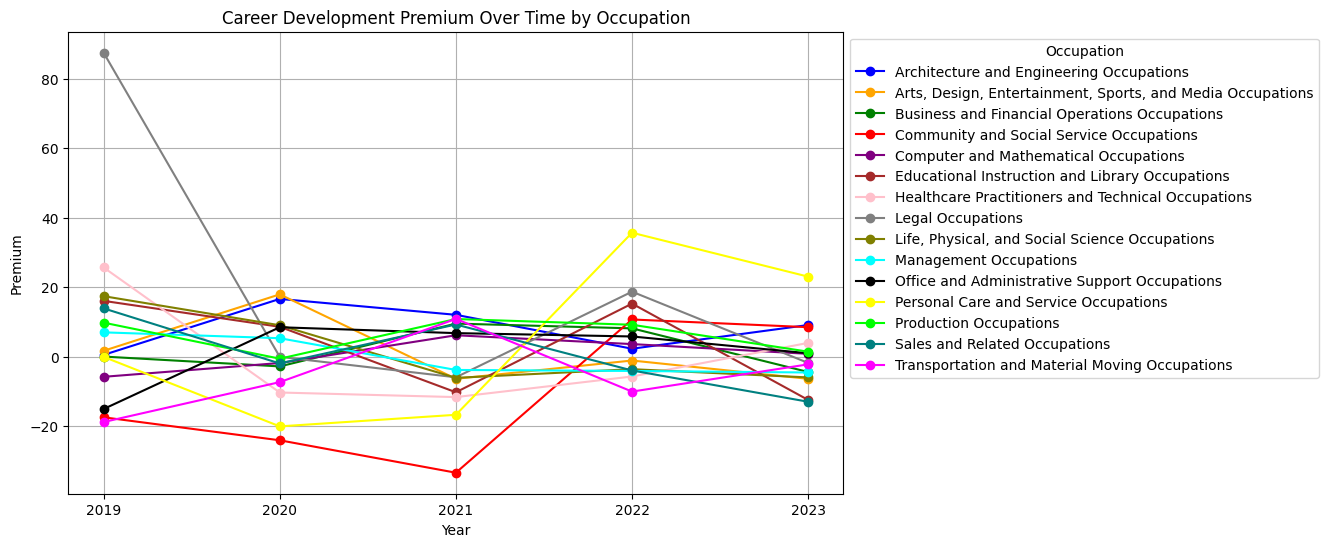

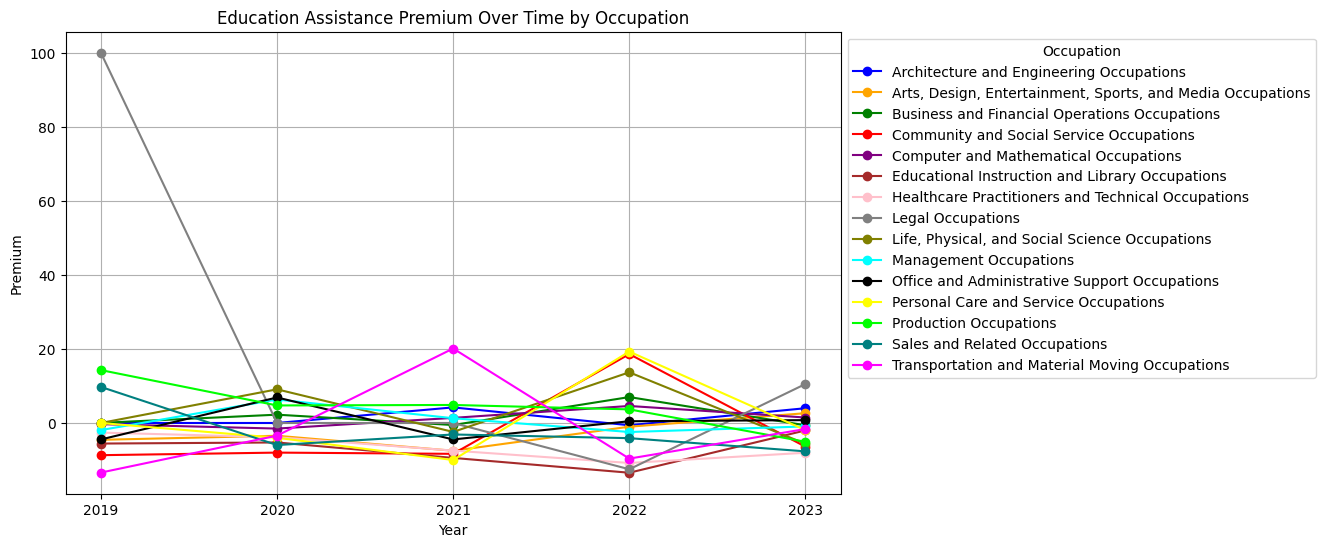

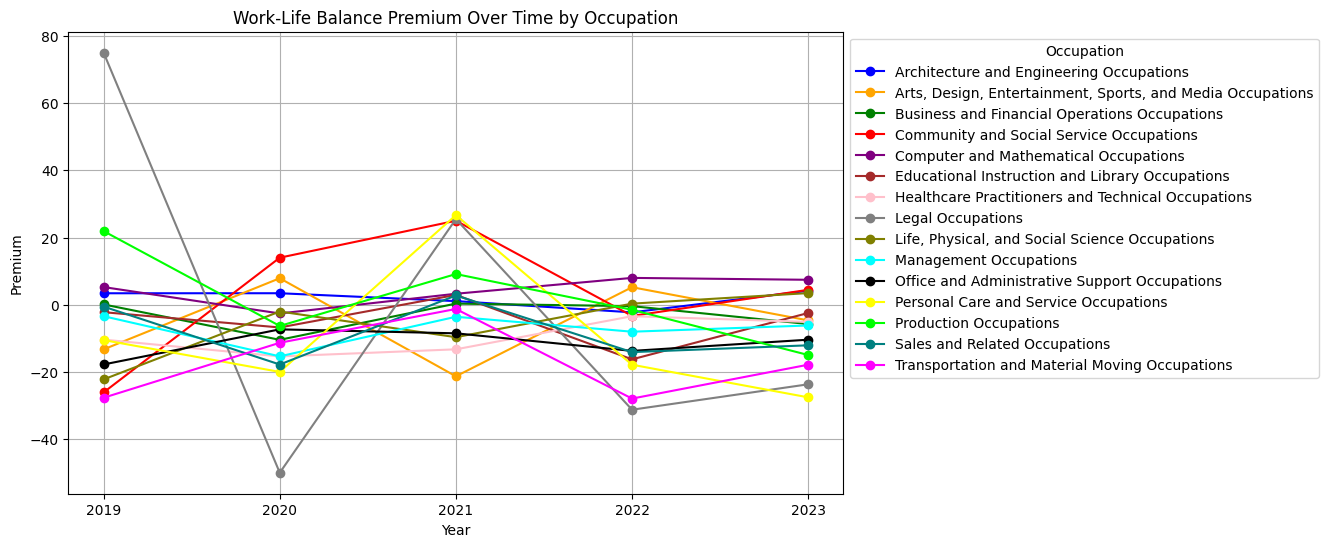

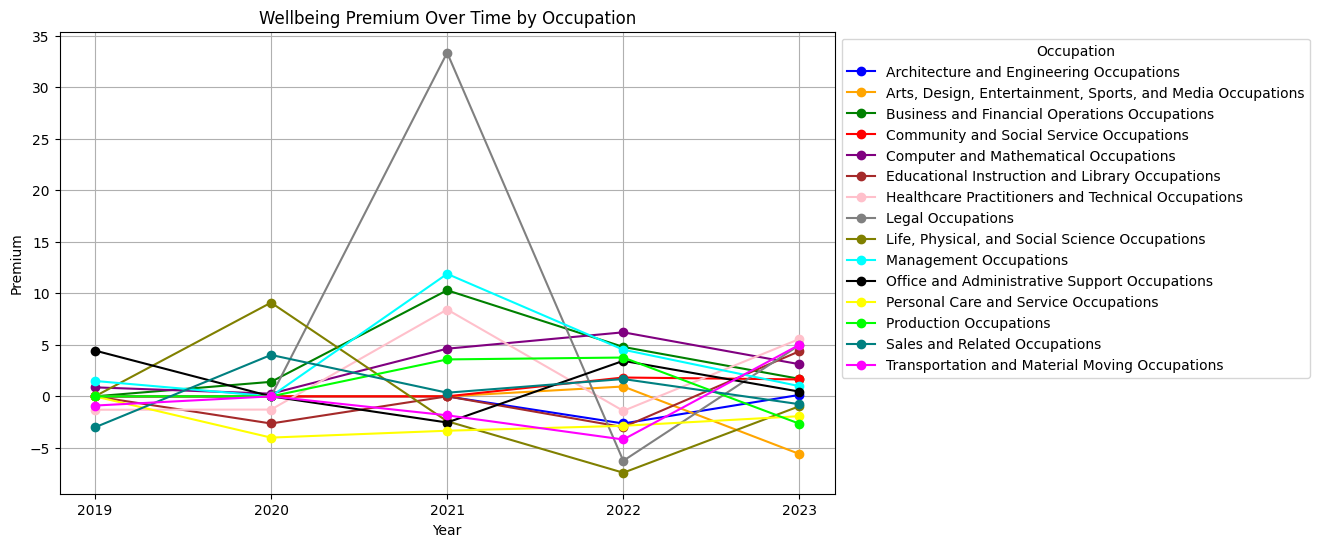

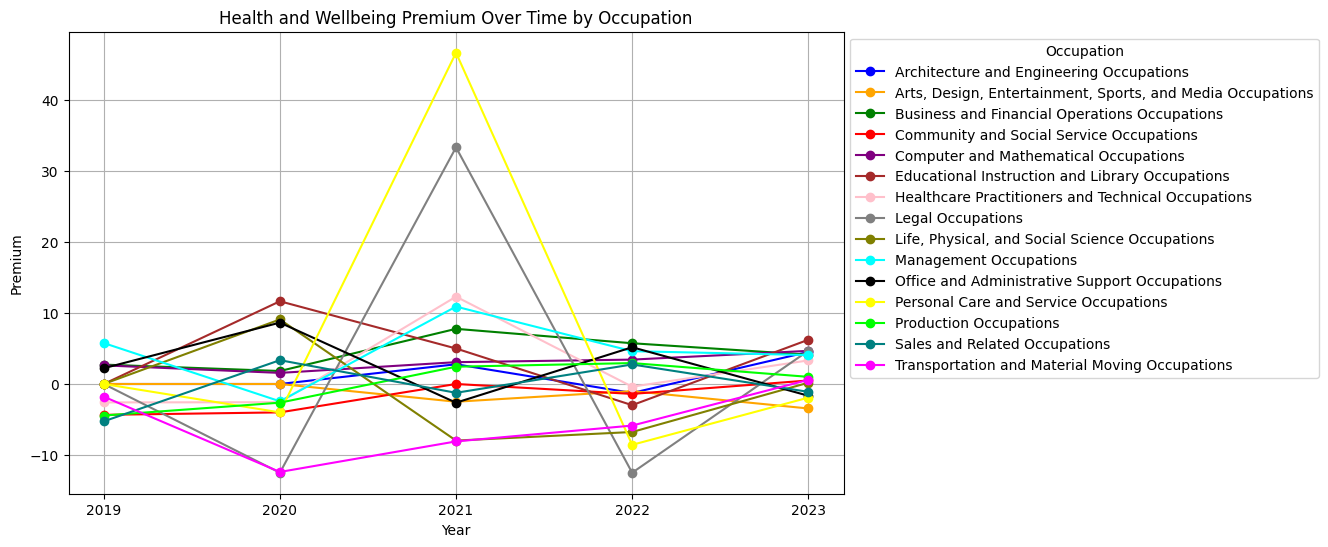

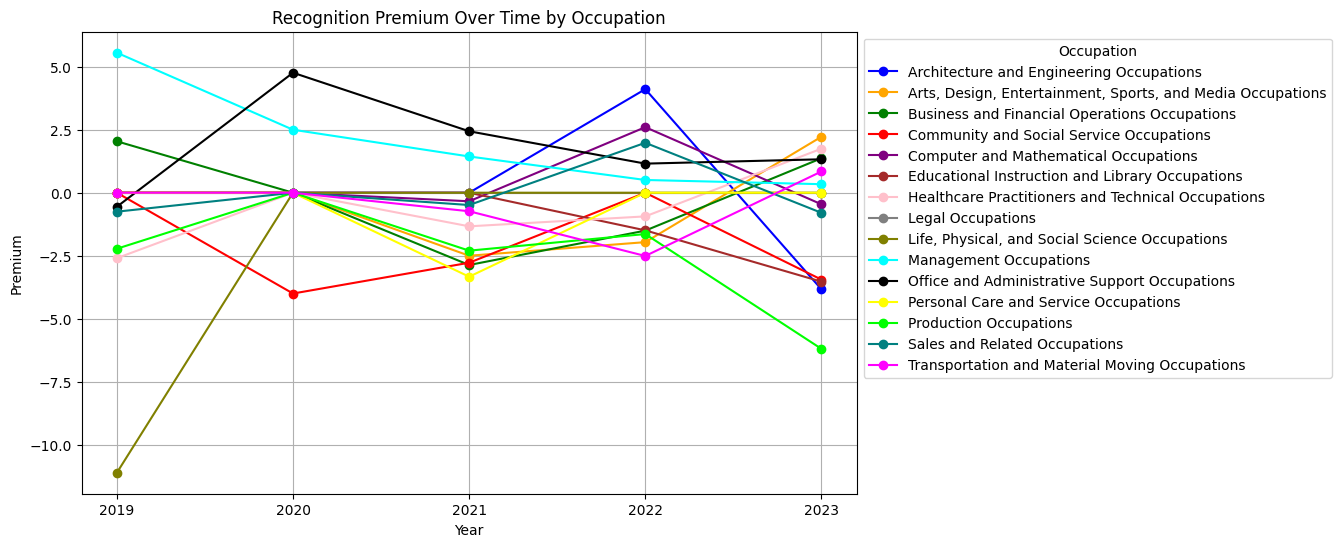

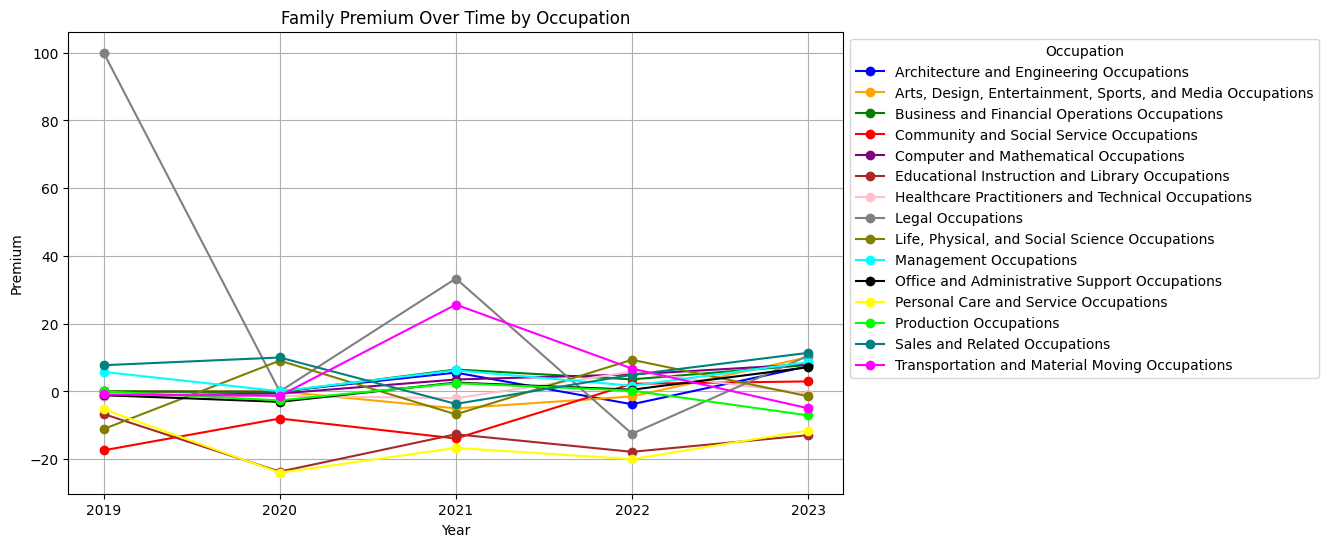

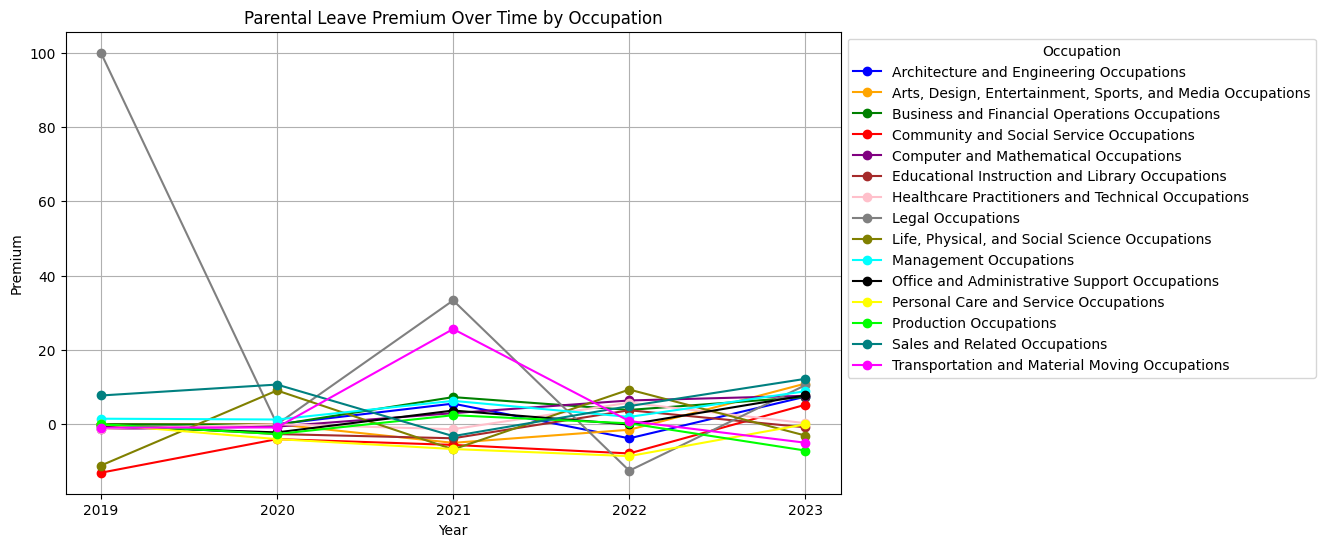

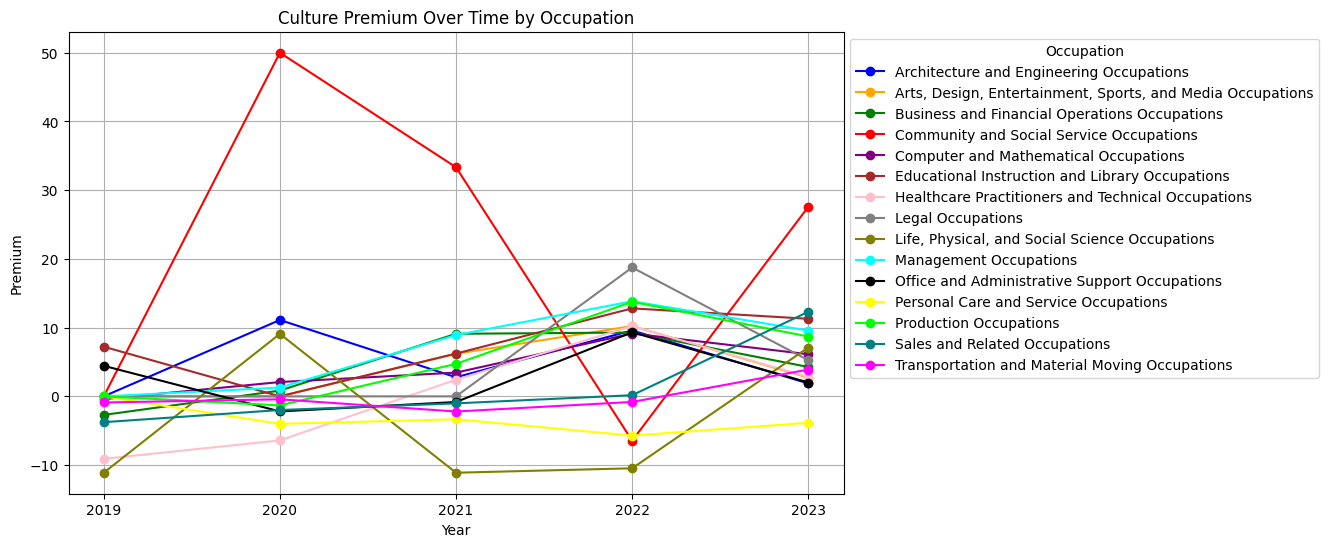

In [112]:
import matplotlib.pyplot as plt

# use different colors for each occupation
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'black', 'yellow', 'lime', 'teal', 'magenta']

for i, benefit in enumerate(benefits3):
    
    # Create a pivot table where the index is 'YEAR' and columns are 'occupation'
    pivot_data = benefit_premium.pivot(index='YEAR', columns=occupation, values=f'{benefit}_premium')

    # Plot each occupation's percentage of AI roles over time
    pivot_data.plot(figsize=(10, 6), marker='o', color=colors)
    benefit_label = benefits3_labels[i]
    # Adding titles and labels
    plt.title(f'{benefit_label} Premium Over Time by Occupation')
    # make x ticks only year integers
    plt.xticks(np.arange(pivot_data.index.min(), pivot_data.index.max()+1, 1.0))
    plt.xlabel('Year')
    plt.ylabel('Premium')
    plt.legend(title='Occupation', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.savefig(f'../figures/{benefit}_premium_time.png')

    # Show the plot
    plt.show()


In [113]:
occ_year_df = benefit_premium.merge(ai_role_occupation, on=[occupation, 'YEAR'])

In [114]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392


# Monetary Premium

In [129]:
occupation_salaries = occupation_benefits = even_sample_select.groupby([occupation, 'YEAR', 'AI ROLE'])[['LOG_SALARY', 'SALARY']].mean().reset_index()

In [130]:
occupation_salaries_ai = occupation_salaries[occupation_salaries['AI ROLE'] == 1]
occupation_salaries_non_ai = occupation_salaries[occupation_salaries['AI ROLE'] == 0]

In [131]:
occupation_salaries = pd.merge(occupation_salaries_ai, occupation_salaries_non_ai, on=[occupation, 'YEAR'], suffixes=('_ai', '_non_ai'))

In [132]:
occupation_salaries['SALARY_PREMIUM_LOG'] = ((occupation_salaries['LOG_SALARY_ai']/occupation_salaries['LOG_SALARY_non_ai'])*100)

In [133]:
occupation_salaries['SALARY_PREMIUM'] = ((occupation_salaries['SALARY_ai']/occupation_salaries['SALARY_non_ai'])*100)

In [134]:
occupation_salaries

,SOC_2021_2_NAME,YEAR,AI ROLE_ai,LOG_SALARY_ai,SALARY_ai,AI ROLE_non_ai,LOG_SALARY_non_ai,SALARY_non_ai,SALARY_PREMIUM_LOG,SALARY_PREMIUM
0,Architecture and Engineering Occupations,2019,True,11.387150,90796.187500,False,11.304232,87393.727273,100.733518,103.893255
1,Architecture and Engineering Occupations,2020,True,11.597093,116638.722222,False,11.071426,71873.923077,104.747961,162.282393
2,Architecture and Engineering Occupations,2021,True,11.561868,109740.583333,False,11.116007,75378.483871,104.010986,145.586085
3,Architecture and Engineering Occupations,2022,True,11.631612,119629.904110,False,11.372761,97191.000000,102.276066,123.087430
4,Architecture and Engineering Occupations,2023,True,11.673177,124427.569536,False,11.425182,97466.666667,102.170600,127.661665
5,"Arts, Design, Entertainment, Sports, and Media...",2019,True,11.261190,91136.461538,False,10.709071,49025.636364,105.155622,185.895520
6,"Arts, Design, Entertainment, Sports, and Media...",2020,True,11.113737,73104.142857,False,10.543366,42266.965517,105.409760,172.958106
7,"Arts, Design, Entertainment, Sports, and Media...",2021,True,11.057736,69753.521739,False,10.684153,47705.175000,103.496608,146.217935
8,"Arts, Design, Entertainment, Sports, and Media...",2022,True,11.063884,76376.609756,False,10.754831,52980.098039,102.873623,144.160945
9,"Arts, Design, Entertainment, Sports, and Media...",2023,True,11.156510,83305.251852,False,10.803178,55299.859375,103.270630,150.642791


Text(0.5, 1.0, 'Salary Premium Distribution')

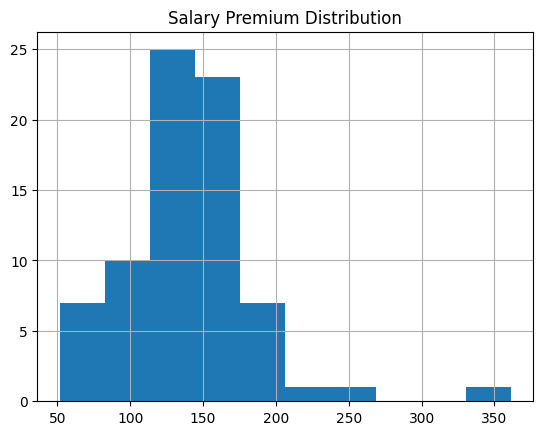

In [136]:
occupation_salaries['SALARY_PREMIUM'].hist()
plt.title('Salary Premium Distribution')

# Change in Demand

In [139]:
ai_role_occupation = ai_role_occupation.sort_values(by=[occupation, 'YEAR'])

In [141]:
ai_role_occupation['AI ROLE % CHANGE'] = ai_role_occupation.groupby(occupation)['AI ROLE %'].pct_change()

In [143]:
ai_role_occupation['AI ROLE % CHANGE'] = ai_role_occupation['AI ROLE % CHANGE']*100

In [144]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %,AI ROLE % CHANGE
0,Architecture and Engineering Occupations,2019,0.592593,NaN
1,Architecture and Engineering Occupations,2020,0.580645,-2.016129
2,Architecture and Engineering Occupations,2021,0.537313,-7.462687
3,Architecture and Engineering Occupations,2022,0.657658,22.397397
4,Architecture and Engineering Occupations,2023,0.782383,18.965150
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581,-12.343470
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079,12.131519
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652,22.069943
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392,52.224537


In [145]:
ai_role_occupation['PRIOR YEAR % CHANGE'] = ai_role_occupation.groupby(occupation)['AI ROLE % CHANGE'].shift(1)

In [146]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392,52.224537,22.069943


In [147]:
occ_year_df = occ_year_df.merge(ai_role_occupation, on=[occupation, 'YEAR'])

In [150]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %_x,AI ROLE %_y,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392,0.678392,52.224537,22.069943


In [152]:
occ_year_df.drop(columns='AI ROLE %_y', inplace=True)

In [153]:
occ_year_df.rename(columns={'AI ROLE %_x':'AI ROLE %'}, inplace=True)

In [154]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392,52.224537,22.069943


In [155]:
occ_year_df = occ_year_df.merge(occupation_salaries, on=[occupation, 'YEAR'])

In [157]:
occ_year_df.drop(columns=['AI ROLE_ai', 'AI ROLE_non_ai'], inplace=True)

# Scatterplots

In [164]:
benefits3

['CAREER_DEV',
 'EDU_ASSISTANCE',
 'WLB',
 'WELLBEING',
 'HEALTH_WELLBEING',
 'RECOGNITION',
 'FAMILY',
 'PARENTAL_LEAVE',
 'CULTURE']

## Vs AI Demand

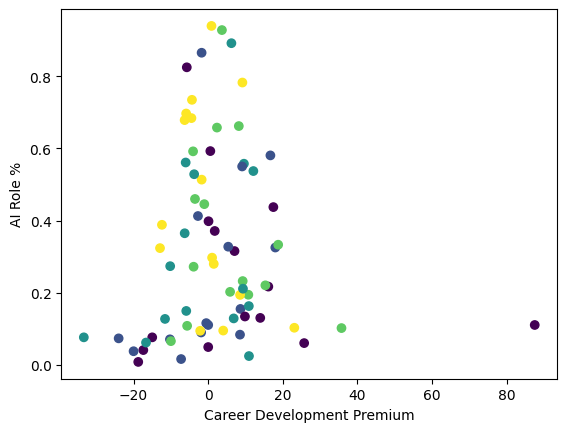

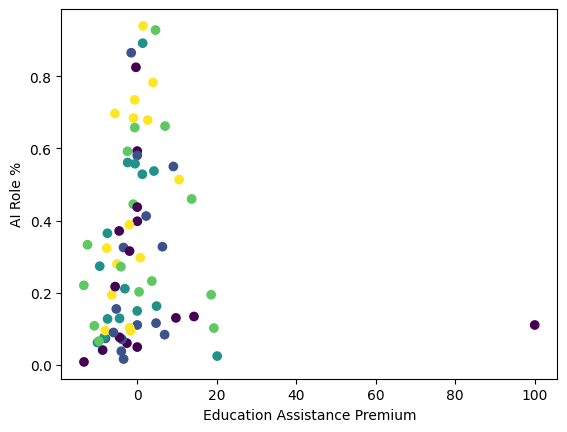

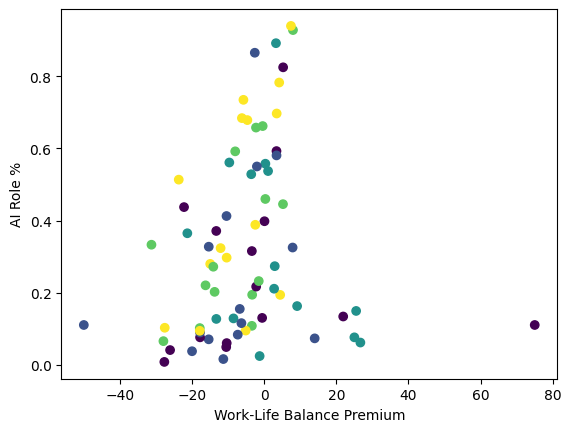

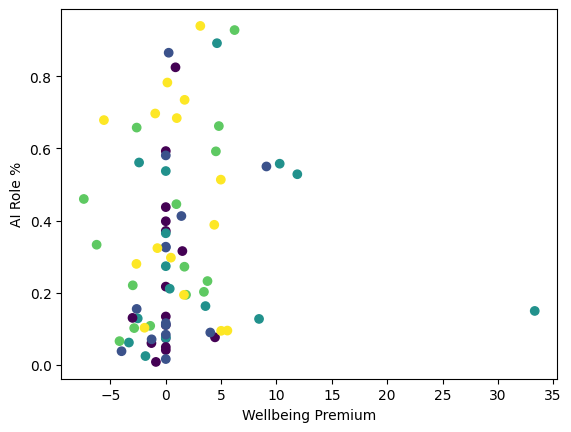

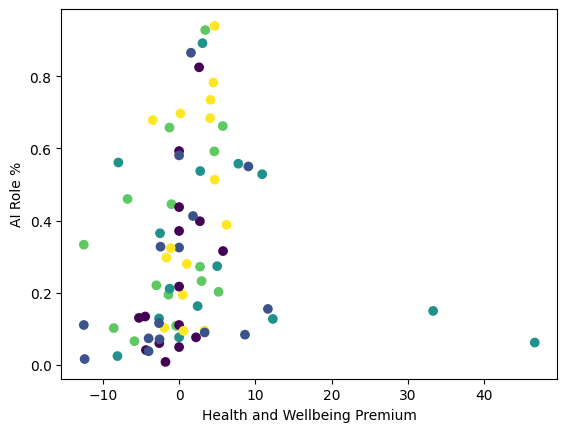

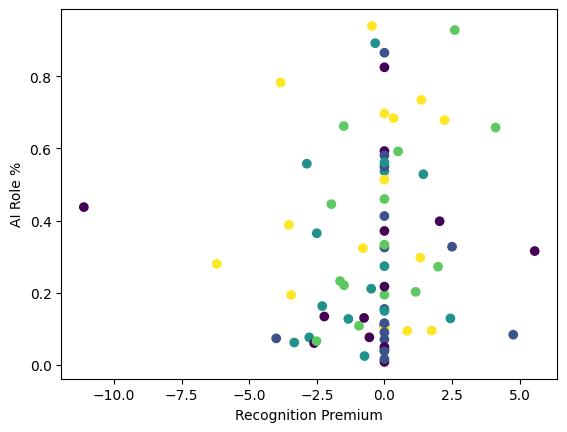

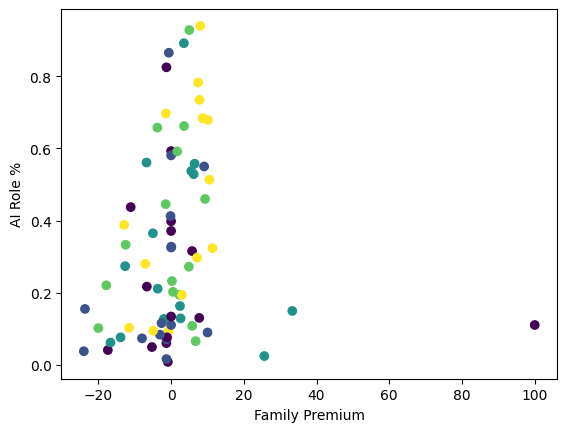

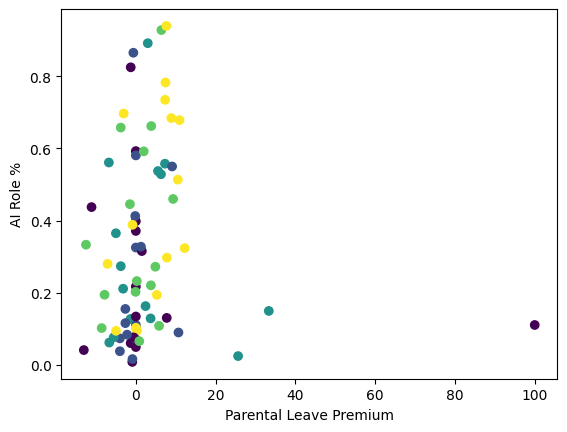

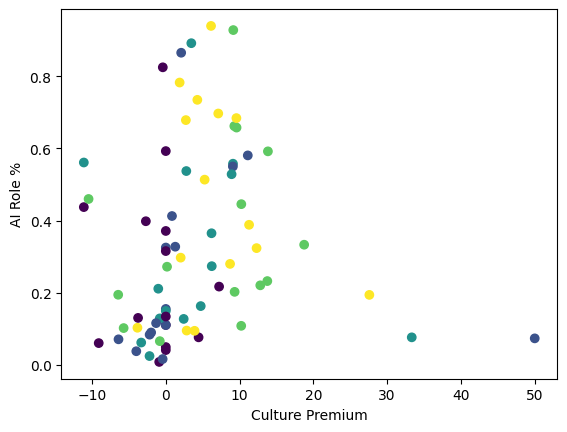

In [167]:
# scatterplot of CAREER PREMIUM vs AI ROLE %
import seaborn as sns
for i, benefit in enumerate(benefits3):
    plt.scatter(occ_year_df[f'{benefit}_premium'], occ_year_df['AI ROLE %'], c=occ_year_df[year])
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.show()


## Color by Occupation

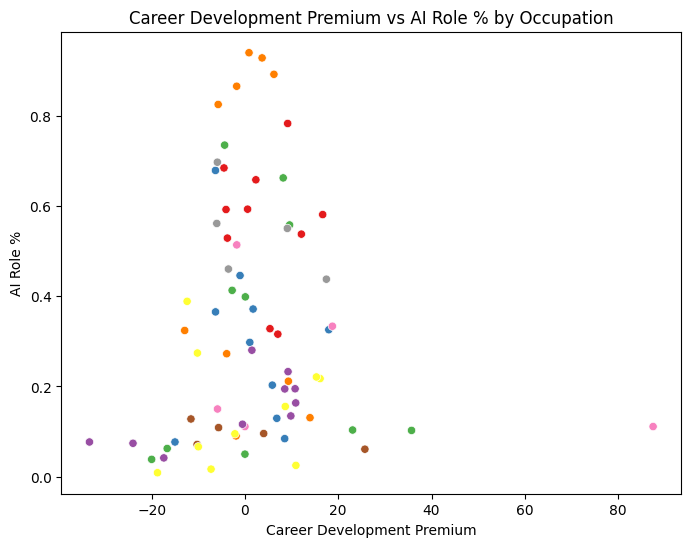

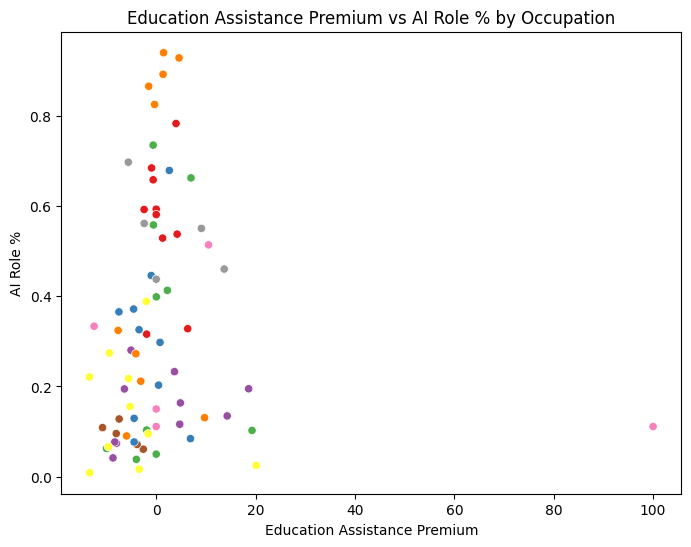

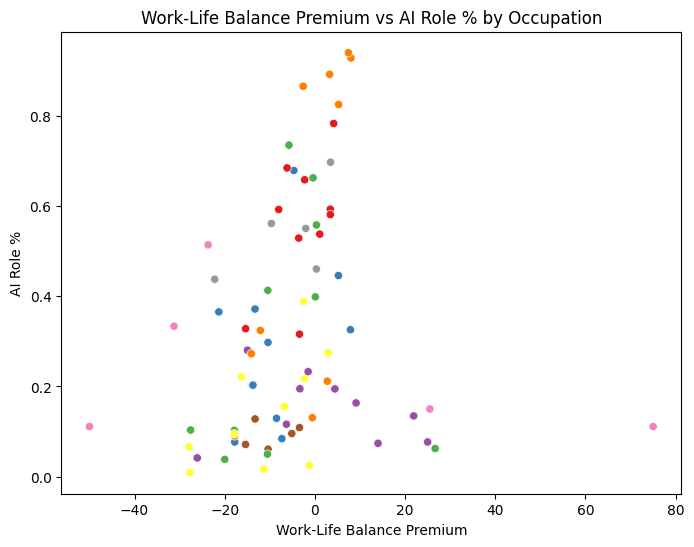

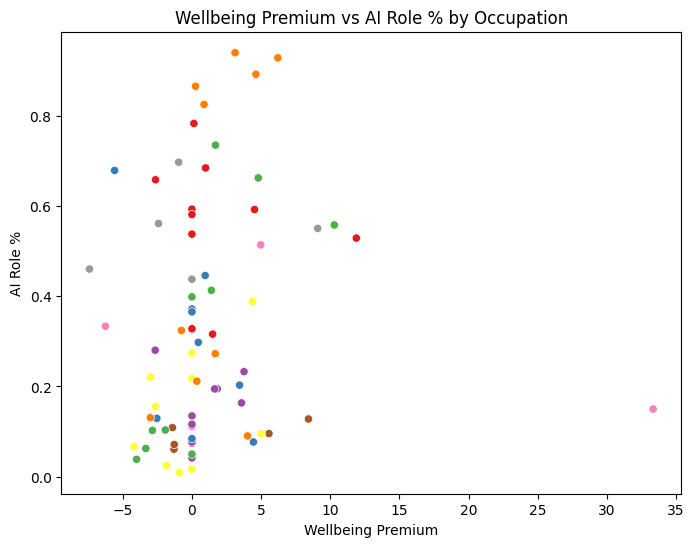

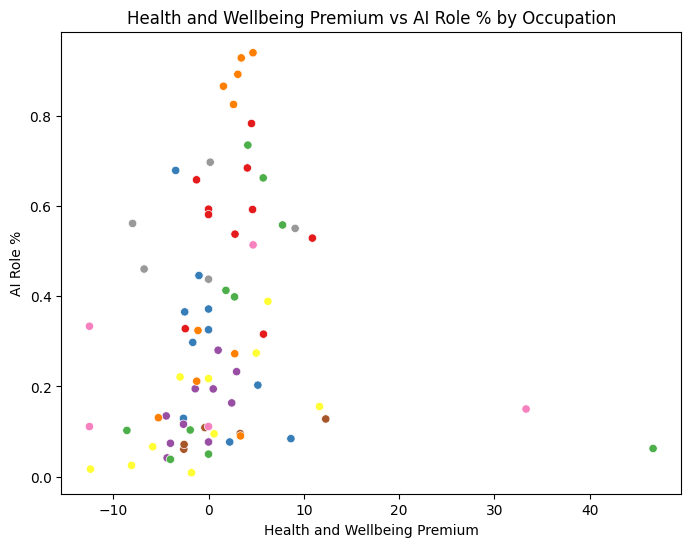

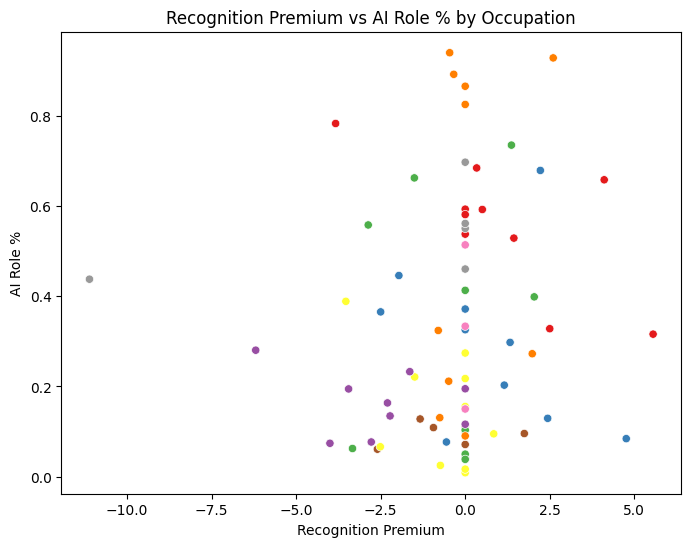

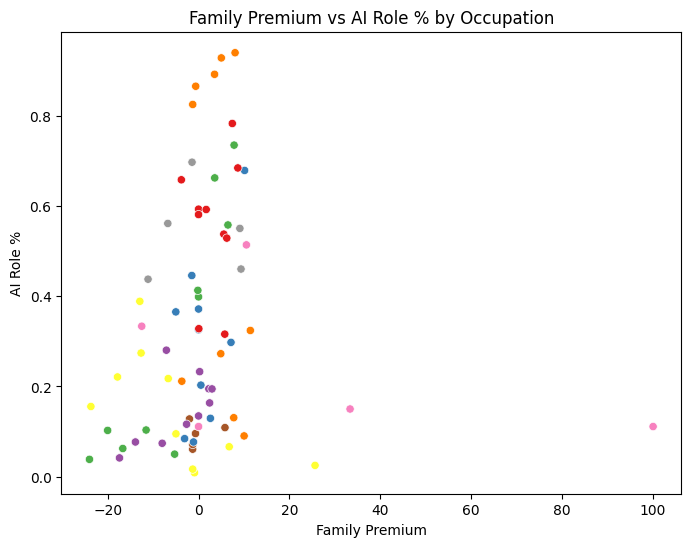

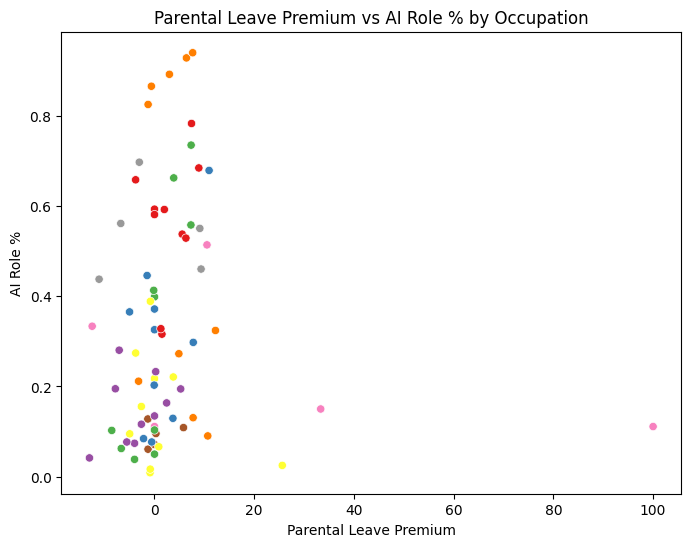

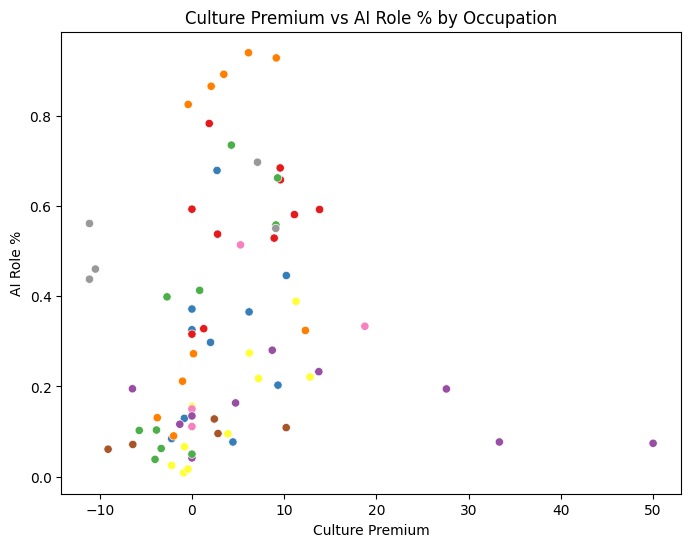

In [179]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    # Remove outliers for each benefit's premium and 'AI ROLE %'
    # filtered_df = remove_outliers(occ_year_df, f'{benefit}_premium')
    # filtered_df = remove_outliers(filtered_df, 'AI ROLE %')
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='AI ROLE %', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role % by Occupation')
    plt.savefig(f'../figures/scatter_premium_vs_ai_demand_{benefit}.png')
    
    # Show the plot
    plt.show()

### Without Outliers

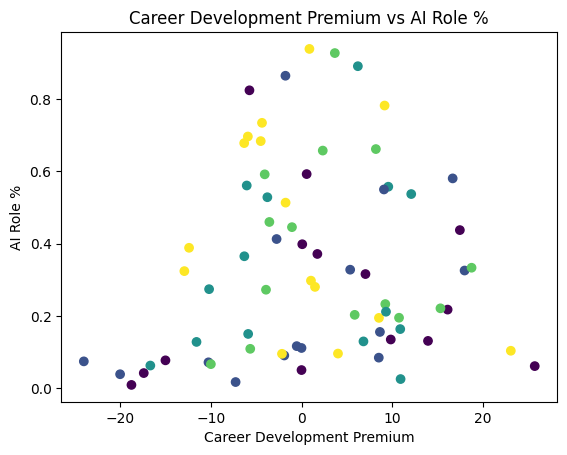

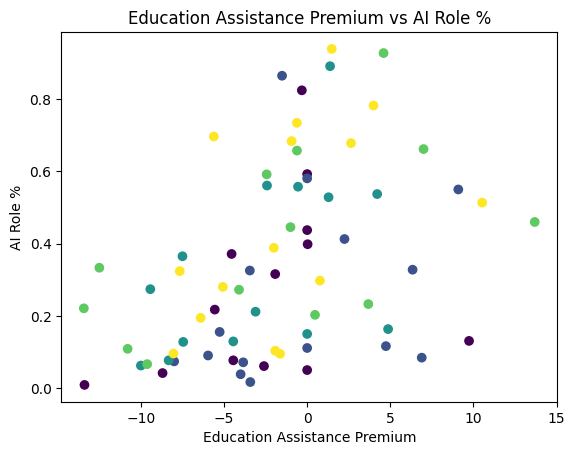

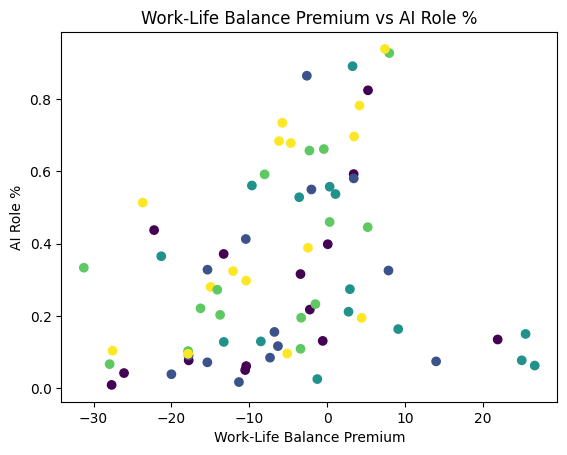

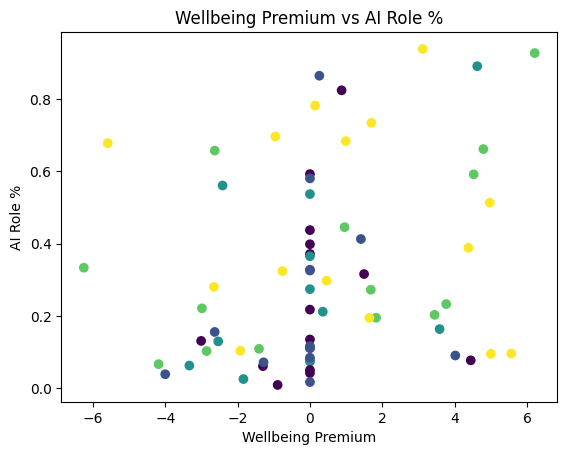

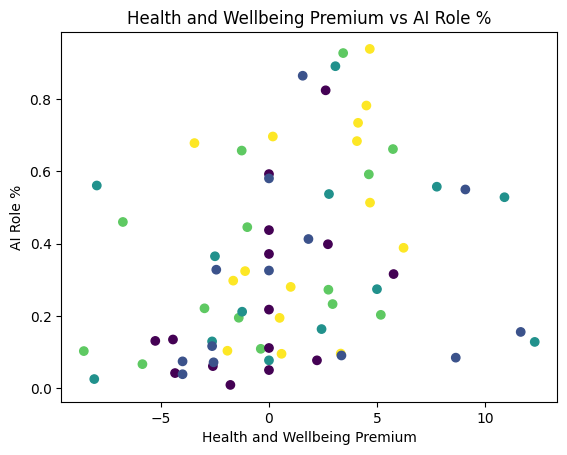

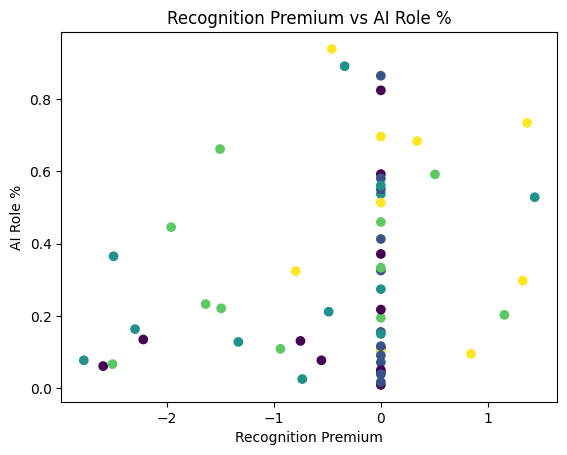

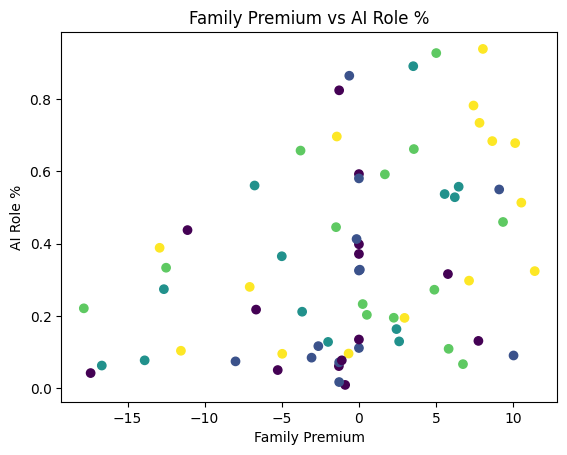

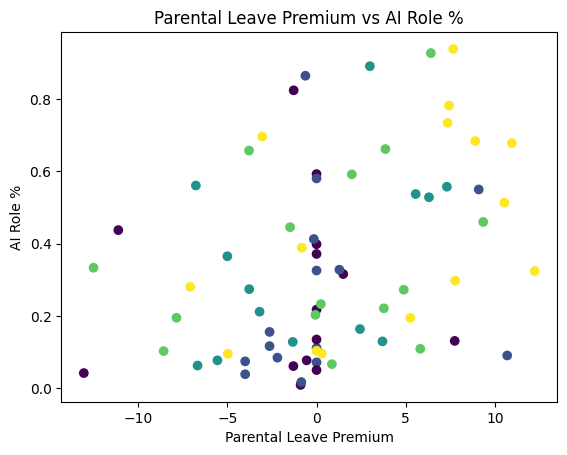

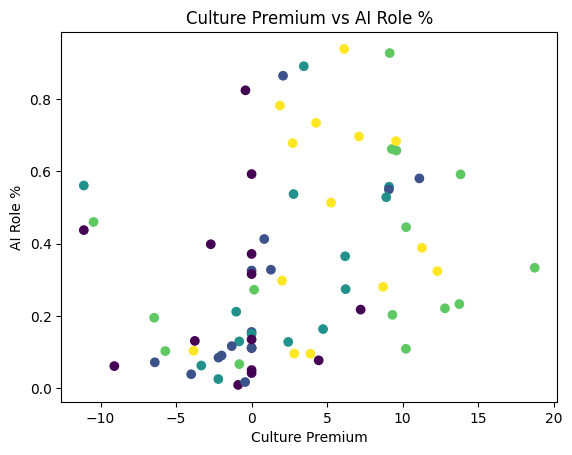

In [165]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Iterate through each benefit and plot the scatterplot without outliers
for i, benefit in enumerate(benefits3):
    # Remove outliers for each benefit's premium and 'AI ROLE %'
    filtered_df = remove_outliers(occ_year_df, f'{benefit}_premium')
    filtered_df = remove_outliers(filtered_df, 'AI ROLE %')
    
    # Plot the scatterplot after removing outliers
    plt.scatter(filtered_df[f'{benefit}_premium'], filtered_df['AI ROLE %'], c=filtered_df[year])
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role %')
    plt.show()

## Change in Demand

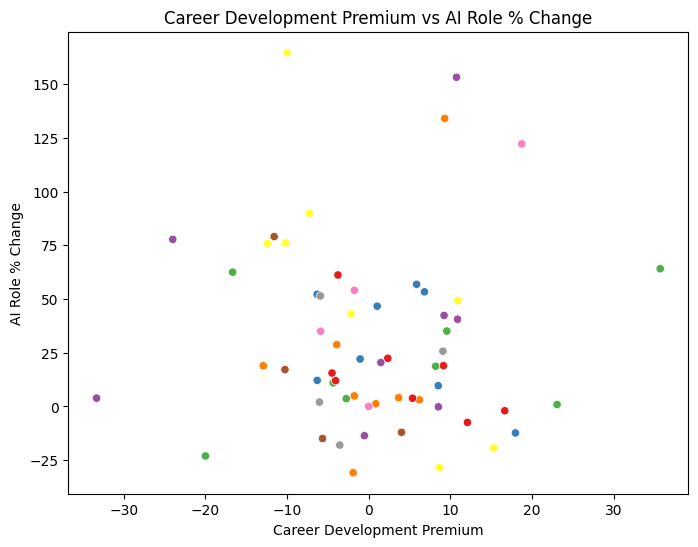

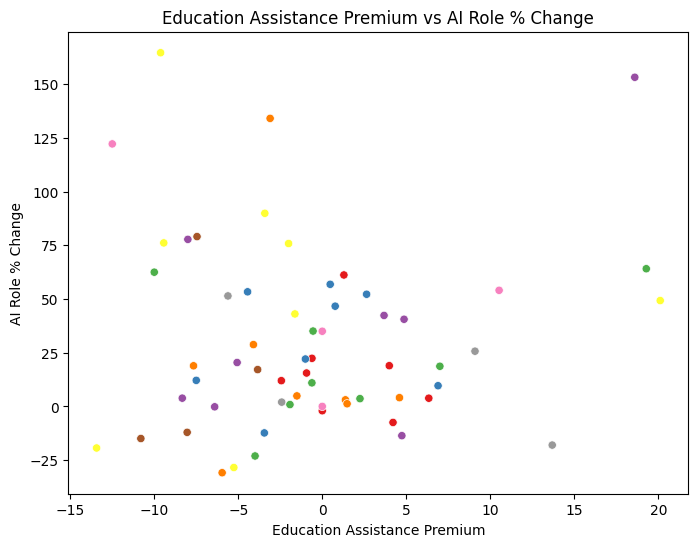

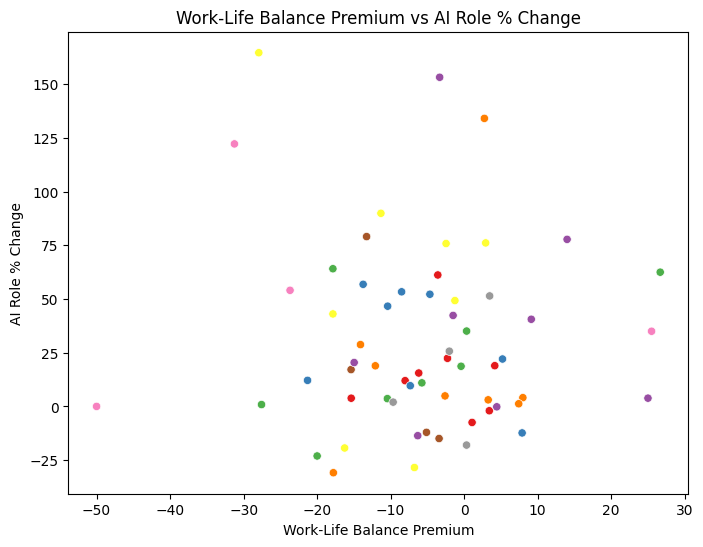

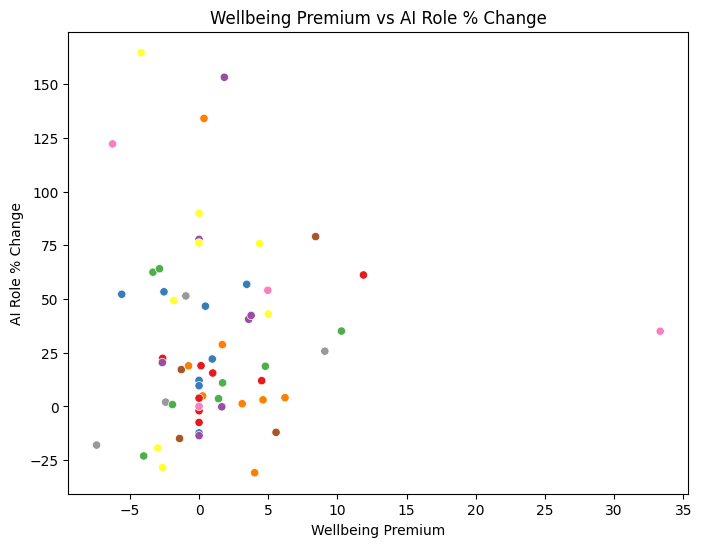

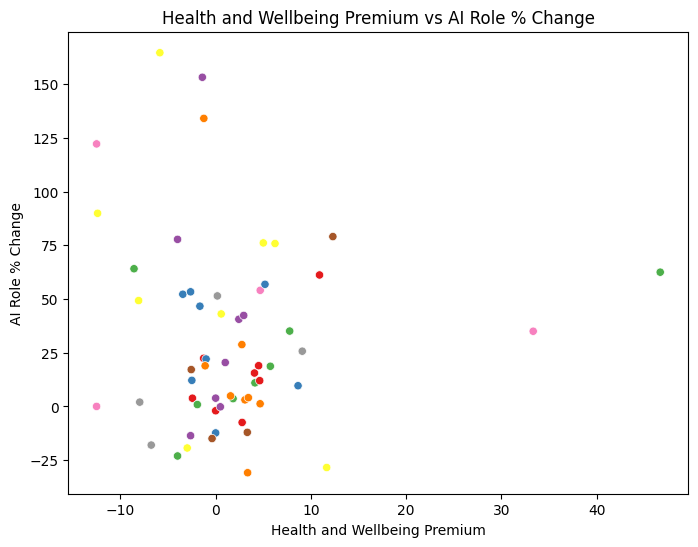

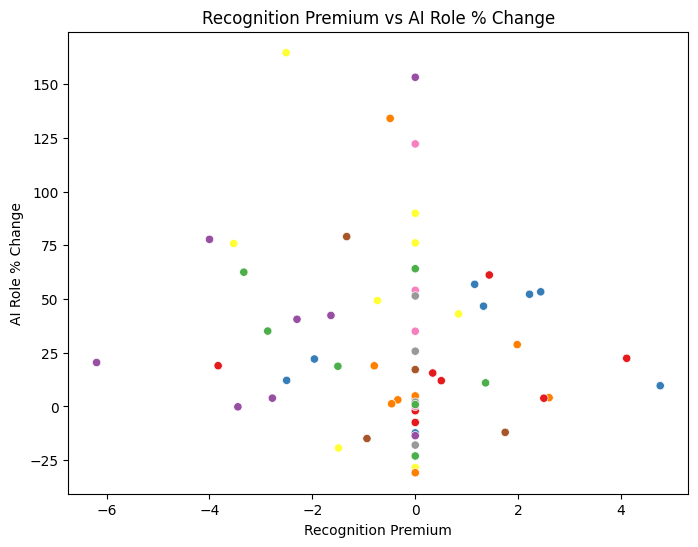

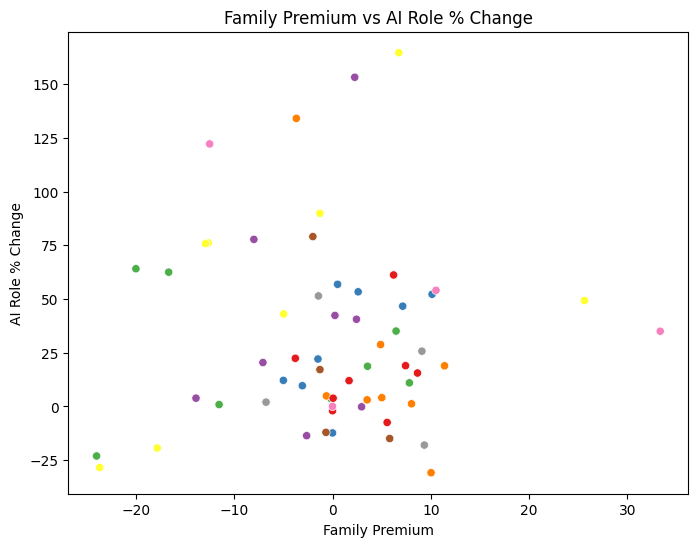

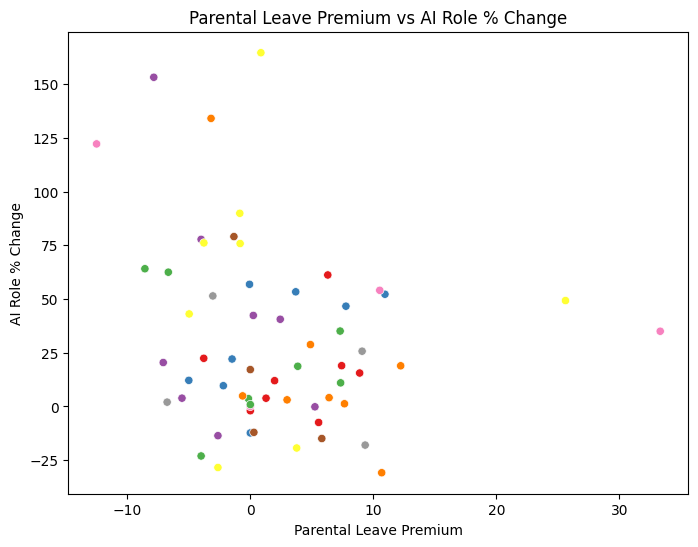

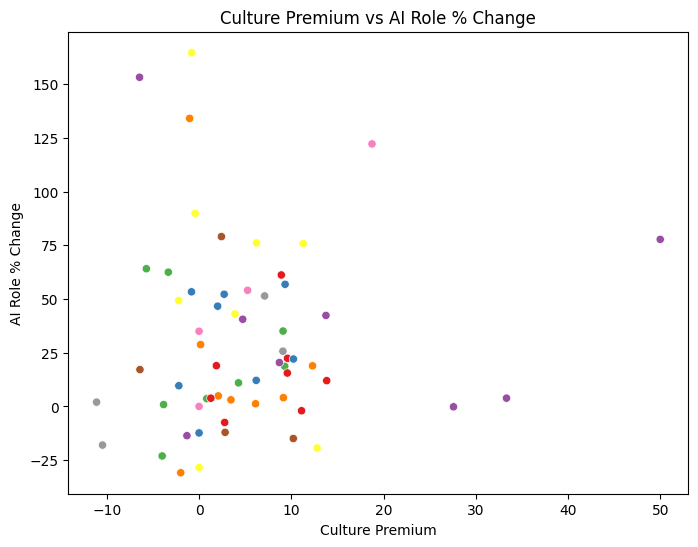

In [180]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='AI ROLE % CHANGE', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role % Change')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role % Change')
    plt.savefig(f'../figures/scatter_premium_vs_ai_demand_change_{benefit}.png')
    
    # Show the plot
    plt.show()

## AI Role Prior Year Change

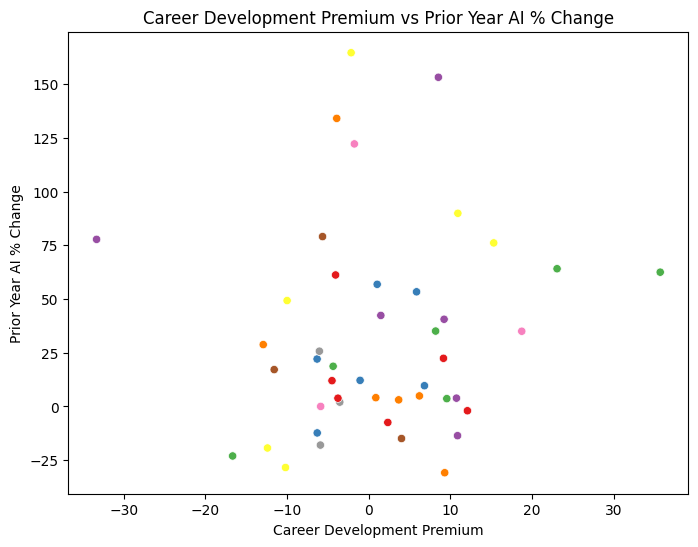

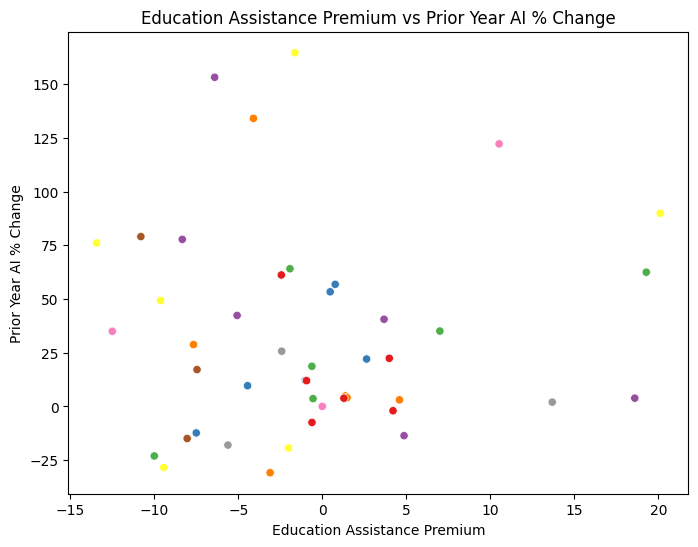

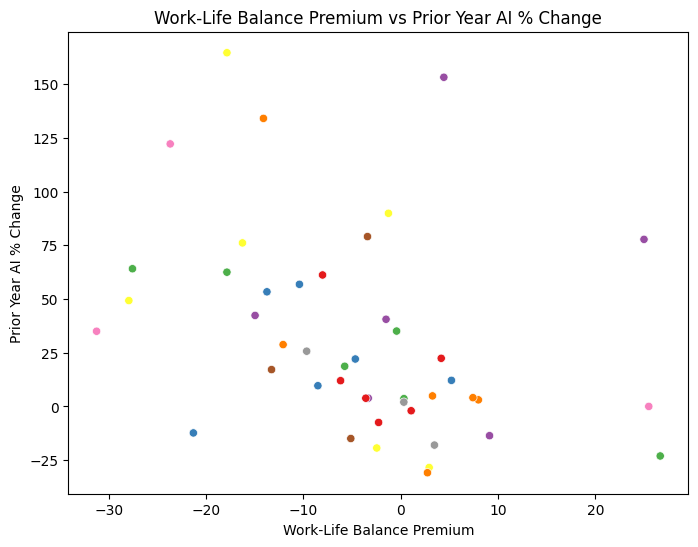

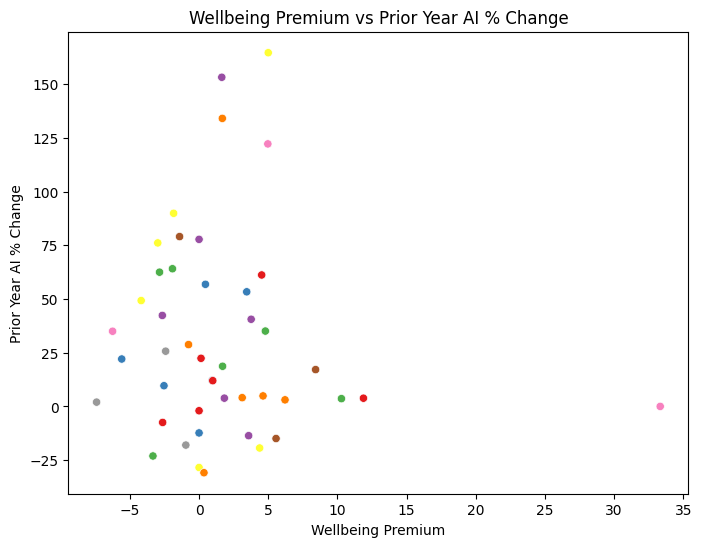

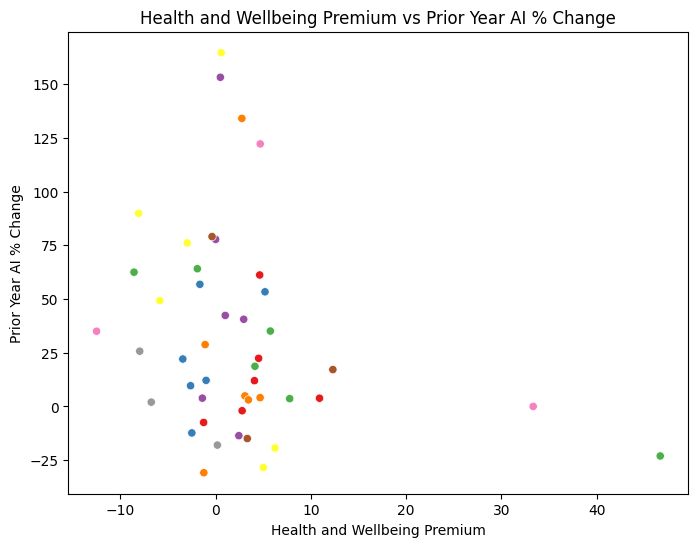

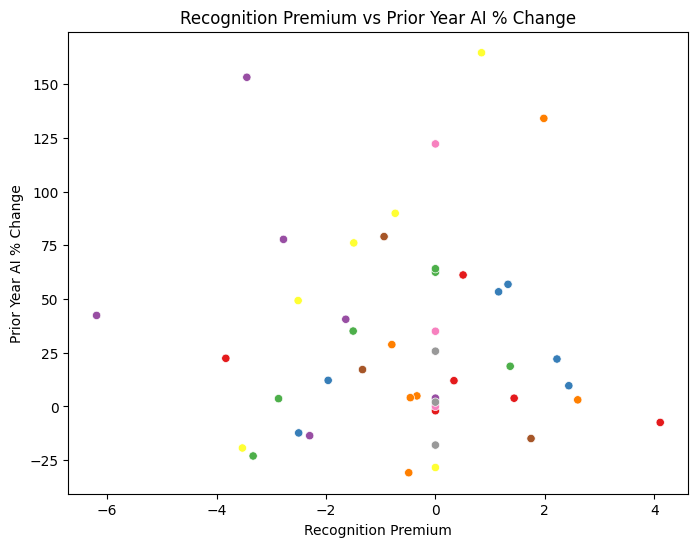

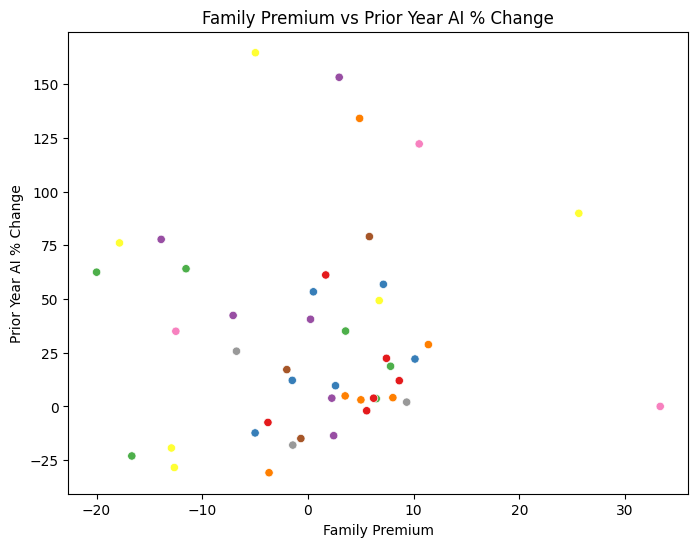

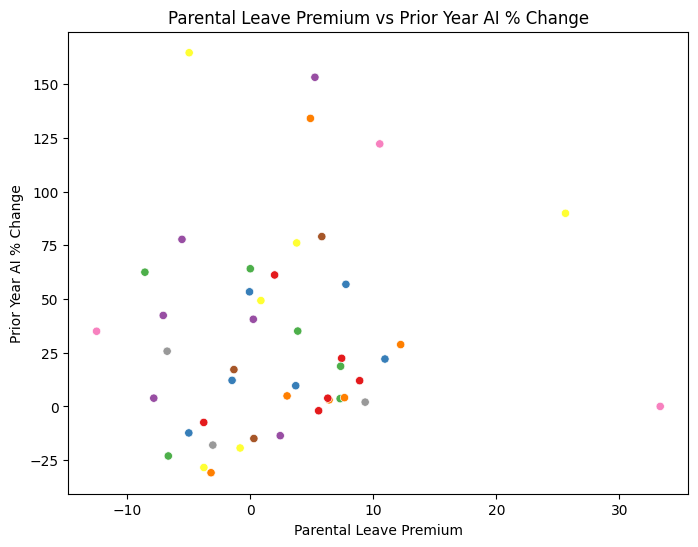

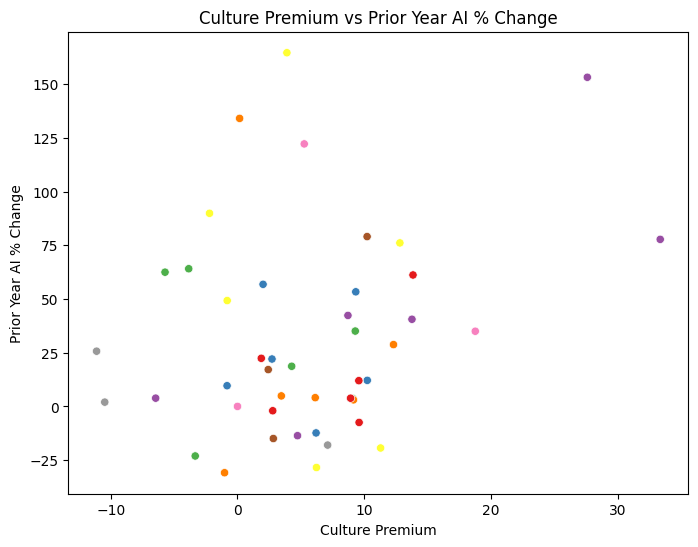

In [183]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='PRIOR YEAR % CHANGE', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('Prior Year AI % Change')
    plt.title(f'{benefits3_labels[i]} Premium vs Prior Year AI % Change')
    plt.savefig(f'../figures/scatter_premium_prior_year_change_{benefit}.png')
    
    # Show the plot
    plt.show()

# Vs. Salary Premium

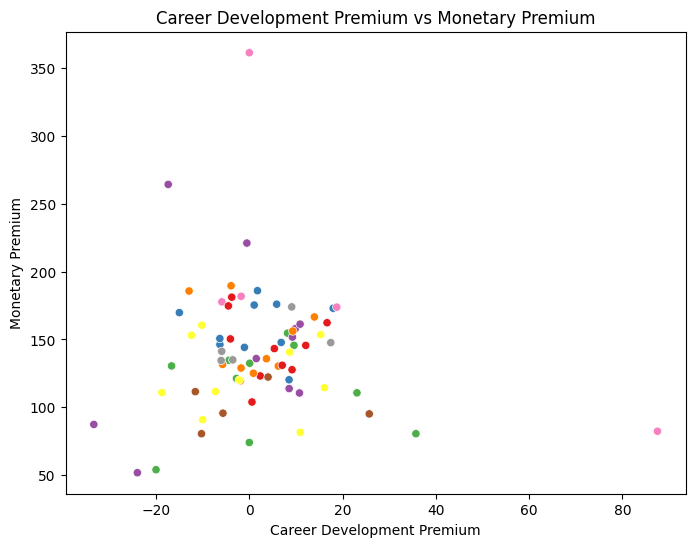

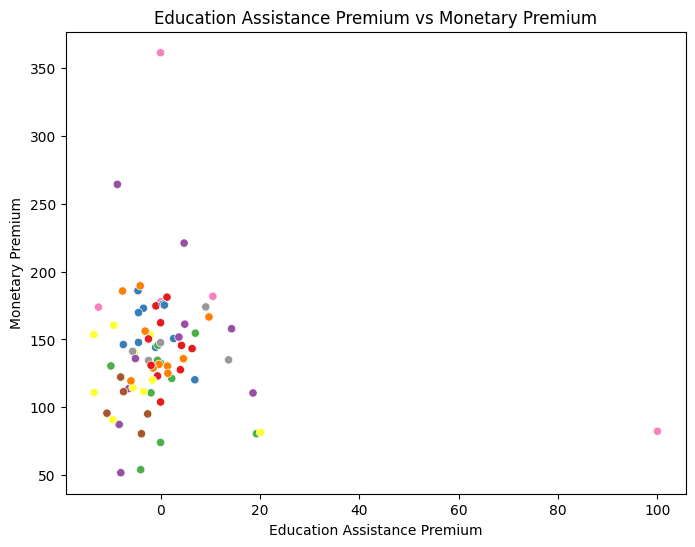

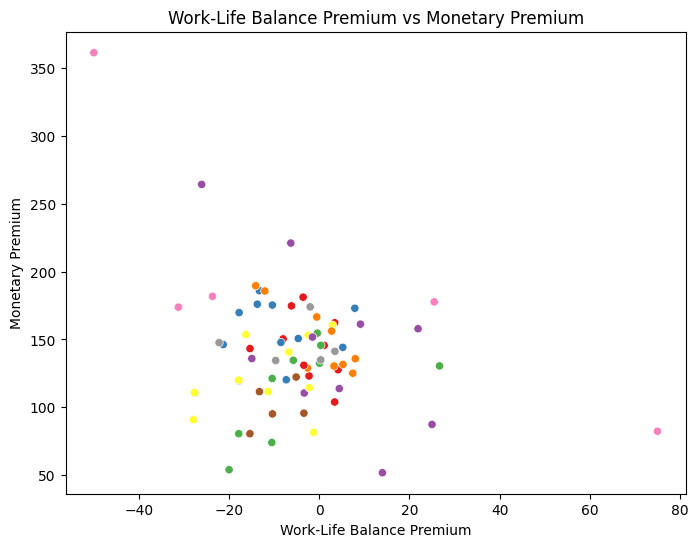

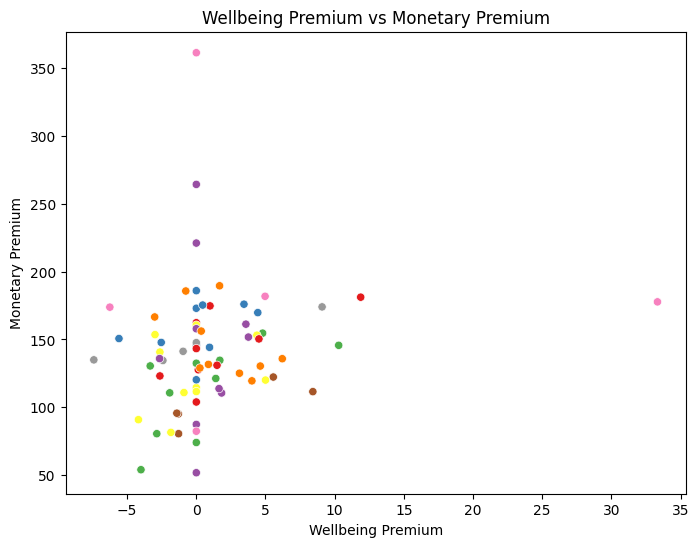

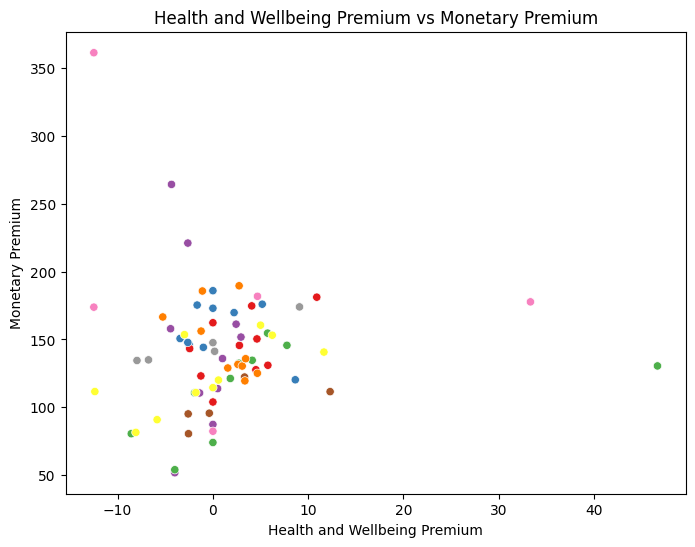

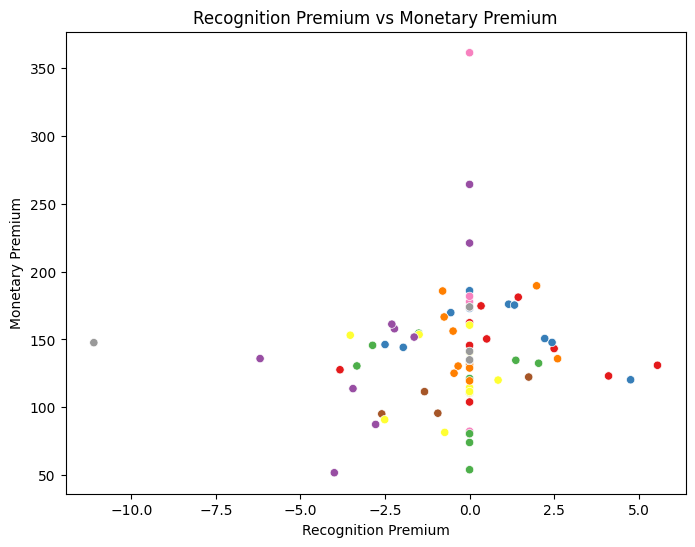

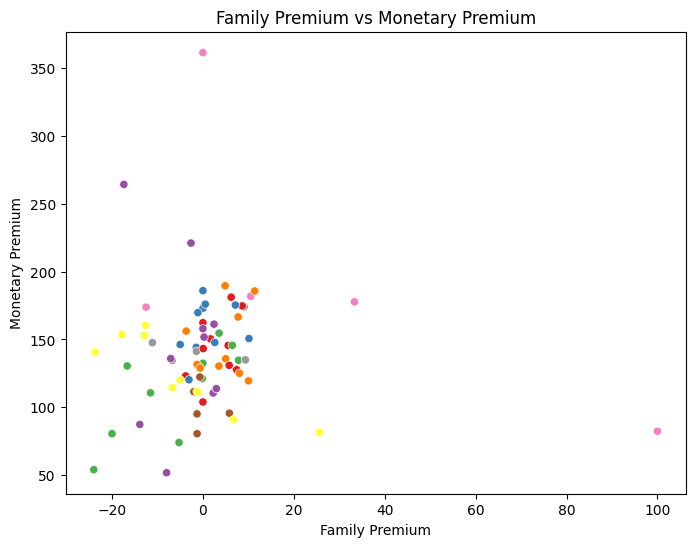

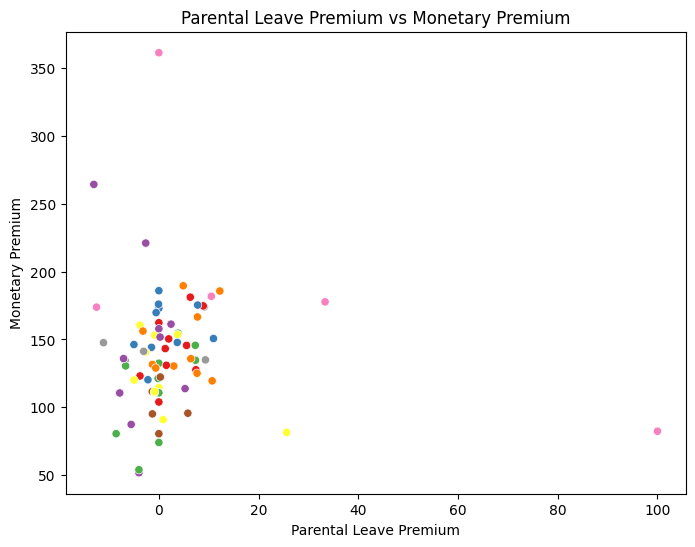

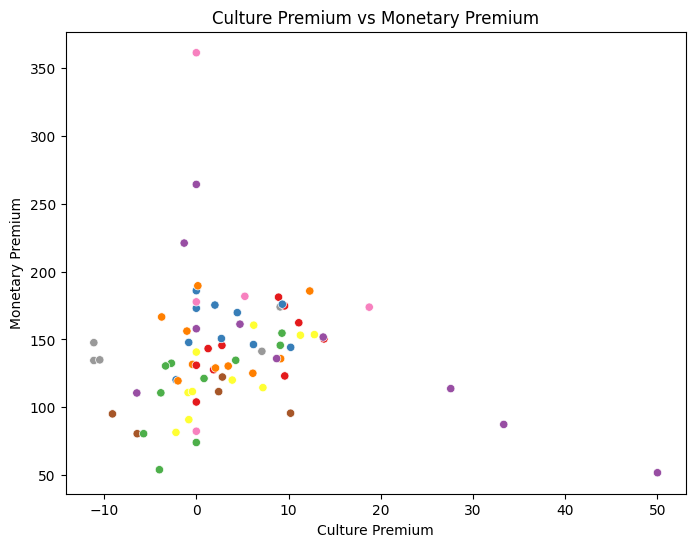

In [182]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='SALARY_PREMIUM', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('Monetary Premium')
    plt.title(f'{benefits3_labels[i]} Premium vs Monetary Premium')
    plt.savefig(f'../figures/scatter_premium_salary_{benefit}.png')
    
    # Show the plot
    plt.show()